<a href="https://colab.research.google.com/github/vivek518455/Weather_dashboard/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os

print(os.listdir('/content'))


['.config', 'spam.zip', 'spam.csv', 'sample_data']


In [25]:
import zipfile

with zipfile.ZipFile('/content/spam.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("ZIP extracted successfully!")


ZIP extracted successfully!


In [26]:
import os
print(os.listdir('/content'))

['.config', 'spam.zip', 'spam.csv', 'sample_data']


In [27]:
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [28]:
# Keep only required columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Convert labels to numeric values
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Display first 5 rows
df.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Shape:")
print(df.shape)

print("\nClass Distribution:")
print(df['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

Dataset Shape:
(5572, 2)

Class Distribution:
label
0    4825
1     747
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

print("Training Matrix Shape:", X_train.shape)
print("Testing Matrix Shape:", X_test.shape)


Training Matrix Shape: (4457, 7472)
Testing Matrix Shape: (1115, 7472)


In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_nb))

print("\nClassification Report")
print(classification_report(y_test, pred_nb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_nb))


Accuracy: 0.9668161434977578

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Confusion Matrix
[[965   0]
 [ 37 113]]


In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

print("\nClassification Report")
print(classification_report(y_test, pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_lr))

Accuracy: 0.9524663677130045

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.67      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115


Confusion Matrix
[[962   3]
 [ 50 100]]


In [34]:
message = ["Congratulations! You have won ₹50,000. Click the link to claim your prize now."]

message_vector = tfidf.transform(message)

prediction = nb.predict(message_vector)

if prediction[0] == 1:
    print("🚨 Spam Message")
else:
    print("✅ Ham (Legitimate) Message")


🚨 Spam Message


In [35]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Naive Bayes Accuracy: 0.9668161434977578
Logistic Regression Accuracy: 0.9524663677130045


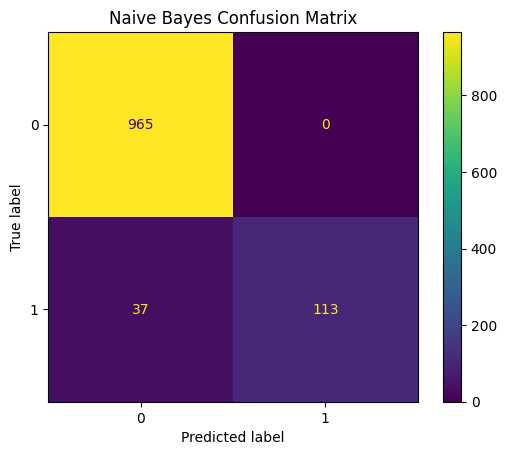

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_nb)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [37]:
import joblib

joblib.dump(nb, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!
